In [3]:
import pandas as pd
df = pd.read_csv("indexing/SNP_haploreg_annotated_20231204.csv",index_col=0)
df["Motifs"]
df_index = pd.read_csv("indexing/index_20240103_curated.csv")#,index_col=0)
#plot the distribution of motif shuffling of certain motif - original. MEF2 for example 
df_motifdisrupt = df_index[df_index["full"].str.contains("motifdisrupt")]
df_index_unique = df[["RSID","Motifs"]].drop_duplicates("RSID")
df_motifdisrupt_annotated = pd.merge(df_motifdisrupt,df_index_unique,on="RSID")
df_motifdisrupt_annotated.to_csv("indexing/motifdisrupt_annotated_20240125.csv",index=False)
df_motifdisrupt_annotated

,full,allele,rsid,center,chr,snp,a1,a2,start,end,summit,Type,RSID,Contributor,nearest_gene,Motifs
0,rs9478143:chr6:150862035:A:G:150861632:1508622...,alt,rs9478143,MOTIFDISRUPT,chr6,150862035.0,A,G,150861632.0,150862271.0,150862051_motifdisrupt,AD,rs9478143,Tanzi,MTHFD1L,STAT_disc6
1,rs9304646:chr19:44947151:T:A:44946977:44947477...,alt,rs9304646,MOTIFDISRUPT,chr19,44947151.0,T,A,44946977.0,44947477.0,44947227_motifdisrupt,AD,rs9304646,Kellis,APOC2,HDAC2_disc6;Ik-2_3;NF-AT1;STAT_known11;Zfp105
2,rs9271174:chr6:32578040:C:G:32577256:32578131:...,alt,rs9271174,MOTIFDISRUPT,chr6,32578040.0,C,G,32577256.0,32578131.0,32578057_motifdisrupt,AD,rs9271174,Pfenning,HLA-DRB1,AP-1_disc5;Mef2_disc3
3,rs9271170:chr6:32577889:T:C:32577256:32578131:...,alt,rs9271170,MOTIFDISRUPT,chr6,32577889.0,T,C,32577256.0,32578131.0,32577812_motifdisrupt,AD,rs9271170,Pfenning,HLA-DRB1,Bcl6b;NRSF_known2;STAT_known6;STAT_known7;Sp100
4,rs9271090:chr6:32576247:T:C:32576044:32576544:...,alt,rs9271090,MOTIFDISRUPT,chr6,32576247.0,T,C,32576044.0,32576544.0,32576294_motifdisrupt,AD,rs9271090,Pfenning,HLA-DRB1,NF-kappaB_disc2;NRSF_disc3;SP1_known3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,rs10769263:chr11:47395632:A:C:47395428:4739592...,alt,rs10769263,MOTIFDISRUPT,chr11,47395632.0,A,C,47395428.0,47395928.0,47395678_motifdisrupt,AD,rs10769263,Kellis,SPI1,Cdc5;Hlx1;Hoxa10;Mef2_known1;Mef2_known3;Mef2_...
160,rs1017204:chr19:33879678:C:T:33879565:33879791...,alt,rs1017204,MOTIFDISRUPT,chr19,33879678.0,C,T,33879565.0,33879791.0,33879678_motifdisrupt,AD,rs1017204,Tanzi,KCTD15,Irf_disc5
161,rs10130373:chr14:92466231:C:A:92465994:9246649...,alt,rs10130373,MOTIFDISRUPT,chr14,92466231.0,C,A,92465994.0,92466494.0,92466244_motifdisrupt,AD,rs10130373,Kellis,SLC24A4,BCL_disc1;ELF1_disc1;ELF1_known1;Ehf;Elf3;Ets_...
162,rs1004173:chr6:47445017:C:T:47444925:47446243:...,alt,rs1004173,MOTIFDISRUPT,chr6,47445017.0,C,T,47444925.0,47446243.0,47444993_motifdisrupt,AD,rs1004173,Pfenning,CD2AP,MZF1::1-4_2;Pax-4_3;STAT_disc7


In [4]:
def annotate_motif(new_column_name,motif,df_motifdisrupt_annotated,df_index):
    df_mef = pd.DataFrame()
    for m in motif:
        df_mef = pd.concat([df_mef,df_motifdisrupt_annotated[df_motifdisrupt_annotated["Motifs"].str.contains(m)]])
    df_index[new_column_name] = df_index["RSID"].apply(lambda x:1 if x in set(df_mef['RSID']) else 0)
    return df_index

df_index = annotate_motif("Mef2",["Mef2"],df_motifdisrupt_annotated,df_index)
df_index[df_index["Mef2"]==1]

df_motifdisrupt_annotateddf_index = annotate_motif("PU.1",["PU.1","SPI1"],df_motifdisrupt_annotated,df_index)
df_index[df_index["PU.1"]==1]

df_motifdisrupt_annotateddf_index = annotate_motif("Irf",["Irf"],df_motifdisrupt_annotated,df_index)
df_index[df_index["Irf"]==1]

df_motifdisrupt_annotateddf_index = annotate_motif("STAT",["STAT"],df_motifdisrupt_annotated,df_index)
df_index[df_index["STAT"]==1]

df_motifdisrupt_annotateddf_index = annotate_motif("NF-kappaB",["NF-kappaB"],df_motifdisrupt_annotated,df_index)
df_index[df_index["NF-kappaB"]==1]

df_motifdisrupt_annotateddf_index = annotate_motif("AP-1",["AP-1"],df_motifdisrupt_annotated,df_index)
df_index[df_index["AP-1"]==1]
df_index.to_csv("indexing/index_20240125_curated.csv",index=False)

In [6]:
# Importing necessary library
import pandas as pd

# Load the CSV file into a pandas DataFrame, assuming it has no header row
#lookup_table = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_20231117.csv", header=None)
lookup_table = pd.read_csv("indexing/ALT_REF_LookUpTable_amended_20231117.csv", header=None)
# Filter the DataFrame to include only rows where the first column contains 'motifdisrupt'
lookup_motif = lookup_table[lookup_table[0].str.contains("motifdisrupt")]

# Rename columns of the filtered DataFrame for clarity
lookup_motif.columns = ["motif", "ref"]

# Filter the original DataFrame to exclude rows containing 'motifdisrupt' in the first column
lookup_rest = lookup_table[~lookup_table[0].str.contains("motifdisrupt")]

# Rename columns of this second filtered DataFrame for clarity
lookup_rest.columns = ["alt", "ref"]

# Filter 'lookup_rest' to include only rows where 'ref' values are in 'lookup_motif'
lookup_motif_inrest = lookup_rest[lookup_rest["ref"].isin(lookup_motif["ref"].tolist())]

# Merge the 'lookup_motif' and 'lookup_motif_inrest' DataFrames based on the 'ref' column
lookup_motif_snp = pd.merge(lookup_motif, lookup_motif_inrest, on="ref")

# Function to compare elements in 'motif' and 'snp' columns
def compare_elements(row):
    # Split the 'motif' and 'snp' values and compare their respective parts
    motif_element = row['motif'].split(':')[0]
    snp_element = row['alt'].split(':')[1]
    return motif_element == snp_element

# Apply the function to each row and filter the DataFrame based on the comparison
filtered_df = lookup_motif_snp[lookup_motif_snp.apply(compare_elements, axis=1)]

# Save the filtered DataFrame to a new CSV file without the index column
#filtered_df.to_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv", index=None)
filtered_df.to_csv("indexing/ALT_REF_LookUpTable_amended_motif_alt_ref_20240127.csv", index=None)

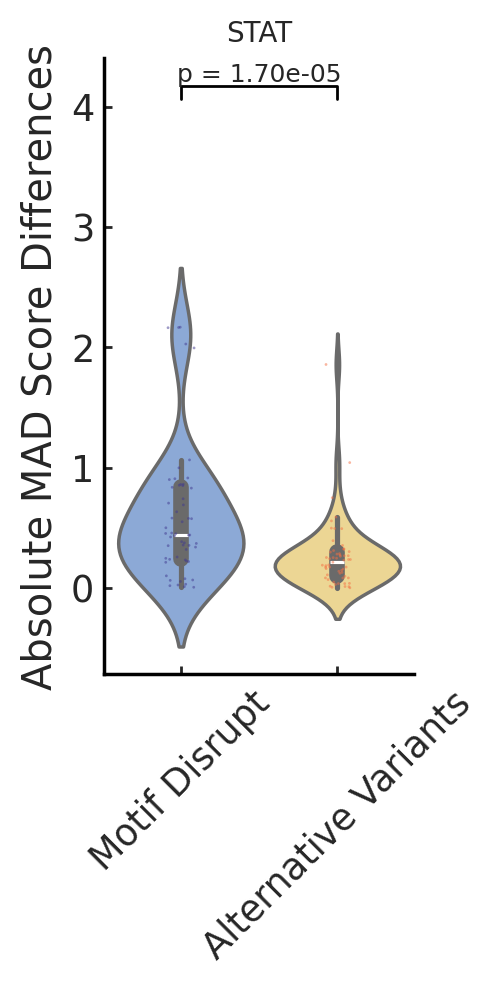

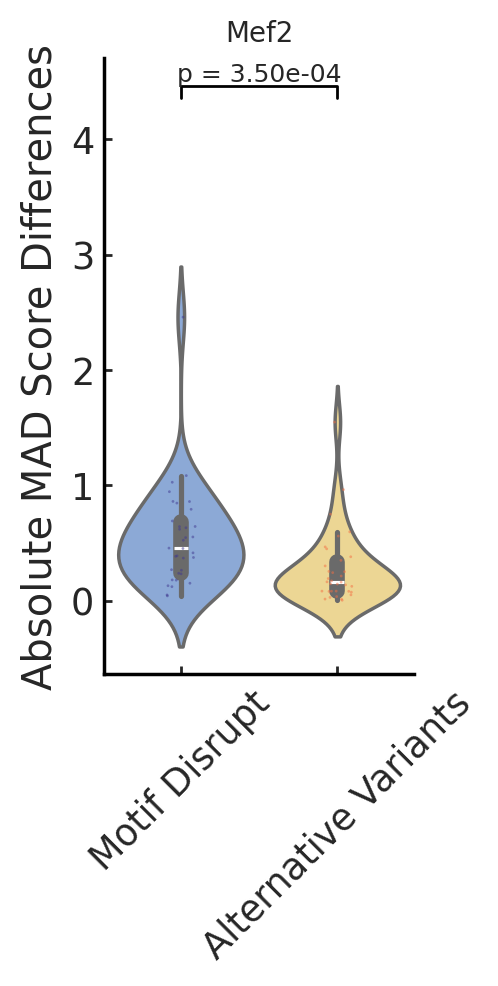

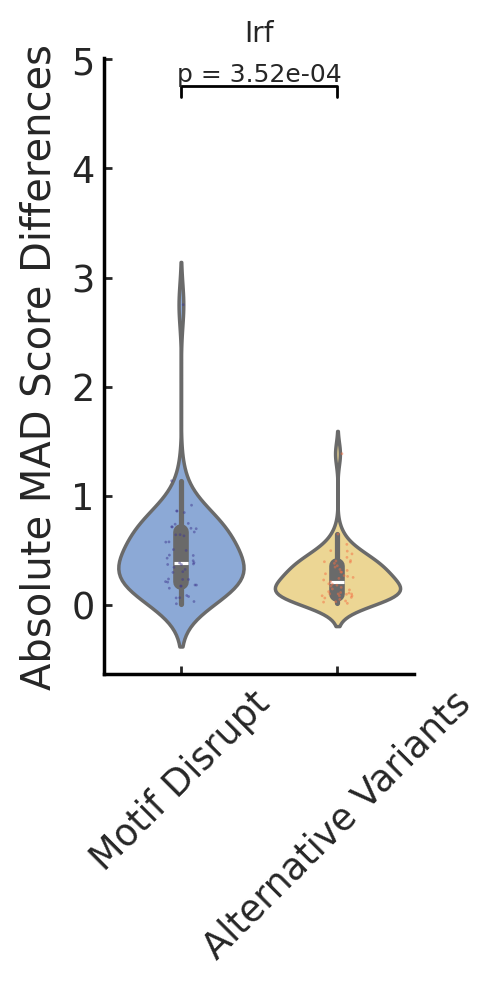

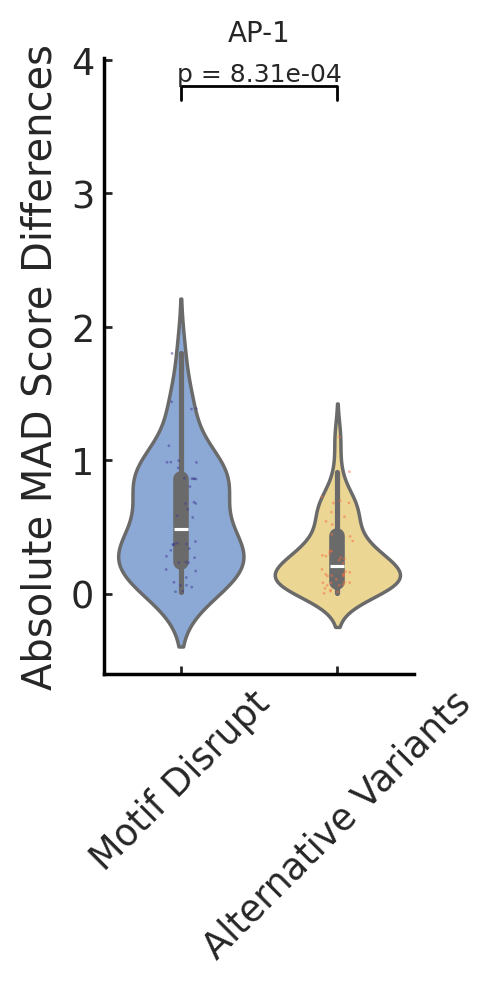

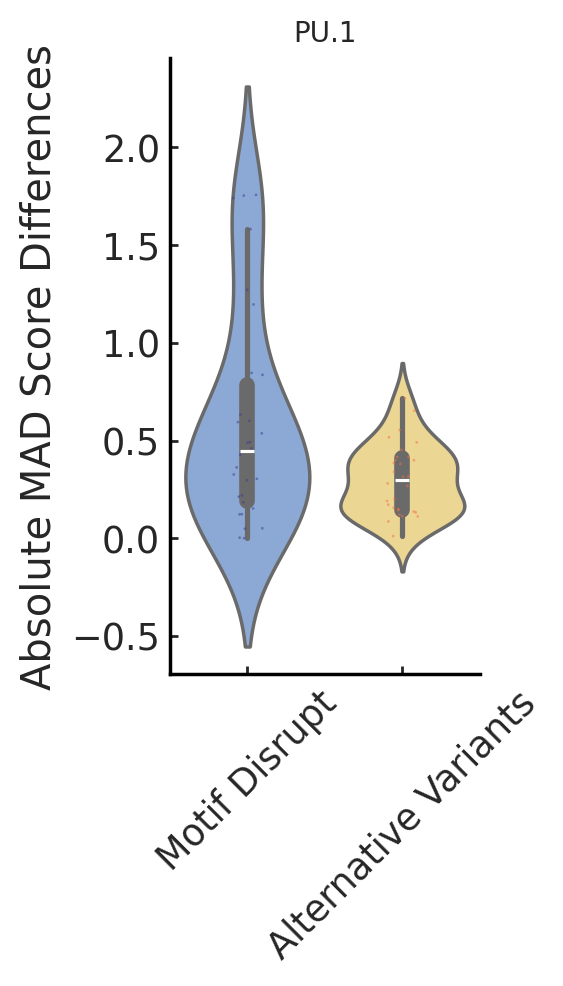

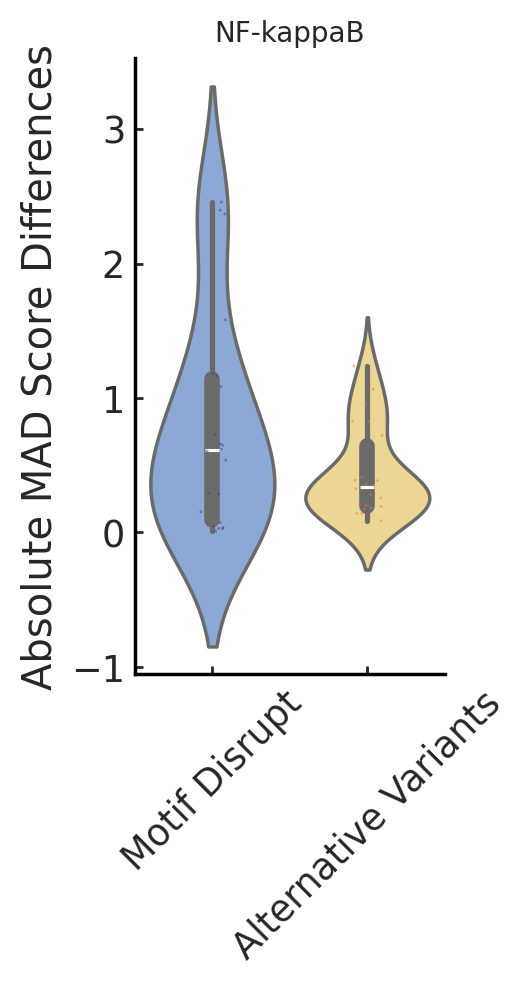

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
def plot_violinplot(combined_data,subset1,title, subset2,offset = 2,):
    # Set seaborn style and increase the resolution
    sns.set(style="whitegrid", font_scale=1.2)
    plt.rcParams['figure.dpi'] = 200

    # Create the plot
    plt.figure(figsize=(2, 4))  # Adjust figure size as needed

    ax = sns.violinplot(x='Condition', y='MAD Score', data=combined_data, palette=["#80A6E2", "#FBDD85"] ,alpha=1)
    sns.stripplot(x='Condition', y='MAD Score', data=combined_data, jitter=True, color='black', alpha=0.5, size=1,palette=['#403990','#F46F43'])

    #Rank sum test
    import scipy.stats as stats
    u_statistic, p_value = stats.mannwhitneyu(subset1, subset2, alternative='two-sided')
    # 如果p值 <= 0.05，在两个条件之间添加一条线和文本
    if p_value <= 0.05:
        # 这里的y坐标值(y_coord)需要根据您的数据进行调整
        y_coord = max(combined_data['MAD Score'])+offset   # 选择适当的y坐标
        plt.plot([0, 0, 1, 1], [y_coord - 0.1, y_coord, y_coord, y_coord - 0.1], lw=1, c='black')
        plt.text(0.5, y_coord, f'p = {p_value:.2e}', ha='center', va='bottom',fontsize=9)

    # Refine grid and axis
    ax.xaxis.grid(False)  # Show x-axis gridlines
    ax.yaxis.grid(False)  # Show y-axis gridlines

    # Make the axis black
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框

    ax.xaxis.set_ticks_position('bottom')  # 在X轴底部显示刻度线
    ax.yaxis.set_ticks_position('left')    # 在Y轴左侧显示刻度线
    plt.xticks(rotation=45)
    ax.tick_params(axis='x', which='major', direction='in', length=3, width=1)
    ax.tick_params(axis='y', which='major', direction='in', length=3, width=1)

    plt.ylabel('Absolute MAD Score Differences')
    plt.xlabel('')
    # Save the figure with high resolution
    #plt.savefig('MAD_Scores_by_Condition.svg', dpi=300, format='svg', bbox_inches='tight')
    plt.title(title,fontsize = 10)
    plt.show()
def process_data(index_file, ref_file, alt_file, filtered_df, motif, statistics):
    # Reading the data
    df_index2 = pd.read_csv(index_file, index_col=0)
    df_ref = pd.read_csv(ref_file, index_col=0)
    df_alt = pd.read_csv(alt_file, index_col=0)

    # Merging with index data
    df_ref = pd.merge(df_ref, df_index2, left_index=True, right_index=True, how='left')
    df_alt = pd.merge(df_alt, df_index2, left_index=True, right_index=True, how='left')

    # Filtering and processing data
    df_alt_index_motif = df_alt[df_alt[motif] == 1]
    df_alt_index_altonly = df_alt_index_motif[df_alt_index_motif.index.isin(filtered_df['alt'])]
    df_alt_final = pd.merge(filtered_df.set_index("alt"), df_alt_index_altonly, right_index=True, left_index=True)
    df_ref_final = df_ref.loc[df_alt_final.index]
    df_motif_final = df_alt.loc[df_alt_final["motif"]]
    df_alt_difference = df_alt_final[statistics] - df_ref_final[statistics]
    df_motif_difference = np.array(df_motif_final[statistics]) - np.array(df_ref_final[statistics])

    # Preparing final DataFrame
    combined_difference_abs = pd.DataFrame({'Shuffled Motifs': abs(df_motif_difference), 'Genetic Variants': abs(np.array(df_alt_difference))}, index=df_alt_difference.index)
    combined_difference_reset = combined_difference_abs.reset_index()
    combined_long = combined_difference_reset.melt(id_vars='index', value_vars=['Shuffled Motifs', 'Genetic Variants'])
    combined_long.columns = ['alt', 'Condition', 'MAD Score']

    return combined_long

# Example usage
filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv") # Load filtered_df from a file or create it before calling the function
combined_long = process_data('indexing/index_20240125_curated.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedREF.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedALT.csv', filtered_df, "STAT", 'mad.score')
# Now use this transformed DataFrame in your plot_violinplot function
plot_violinplot(combined_long, subset1=abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score']), 
                subset2=abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score']), offset=2, title = "STAT")

# Example usage
filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv") # Load filtered_df from a file or create it before calling the function
combined_long= process_data('indexing/index_20240125_curated.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedREF.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedALT.csv', filtered_df, "Mef2", 'mad.score')
# Now use this transformed DataFrame in your plot_violinplot function
plot_violinplot(combined_long, subset1=abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score']), 
                subset2=abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score']), offset=2, title = "Mef2")

# Example usage
filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv") # Load filtered_df from a file or create it before calling the function
combined_long= process_data('indexing/index_20240125_curated.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedREF.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedALT.csv', filtered_df, "Irf", 'mad.score')
# Now use this transformed DataFrame in your plot_violinplot function
plot_violinplot(combined_long, subset1=abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score']), 
                subset2=abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score']), offset=2, title = "Irf")

# Example usage
filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv") # Load filtered_df from a file or create it before calling the function
combined_long= process_data('indexing/index_20240125_curated.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedREF.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedALT.csv', filtered_df, "AP-1", 'mad.score')
# Now use this transformed DataFrame in your plot_violinplot function
plot_violinplot(combined_long, subset1=abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score']), 
                subset2=abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score']), offset=2, title = "AP-1")

# Example usage
filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv") # Load filtered_df from a file or create it before calling the function
combined_long= process_data('indexing/index_20240125_curated.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedREF.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedALT.csv', filtered_df, "PU.1", 'mad.score')
# Now use this transformed DataFrame in your plot_violinplot function
plot_violinplot(combined_long, subset1=abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score']), 
                subset2=abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score']), offset=2, title = "PU.1")

# Example usage
filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv") # Load filtered_df from a file or create it before calling the function
combined_long= process_data('indexing/index_20240125_curated.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedREF.csv', 'enhancer_activities/THP1Macrophage_byAllele/20240105_MPRA3_MAD_mergedALT.csv', filtered_df, "NF-kappaB", 'mad.score')
# Now use this transformed DataFrame in your plot_violinplot function
plot_violinplot(combined_long, subset1=abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score']), 
                subset2=abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score']), offset=2, title = "NF-kappaB")

# 20240912

Differences - Statistics=0.8609605673546249, p-value=1.0287043159831349e-05
Differences: Sample does not look Gaussian (reject H0)
Differences - Statistics=0.9651211407392012, p-value=0.34064091013769443
Differences: Sample looks Gaussian (fail to reject H0)
Differences - Statistics=0.9639173329072657, p-value=0.13728422734150114
Differences: Sample looks Gaussian (fail to reject H0)
Differences - Statistics=0.9256629901933213, p-value=0.00739730345619592
Differences: Sample does not look Gaussian (reject H0)
Differences - Statistics=0.9375041728021576, p-value=0.07792842390971703
Differences: Sample looks Gaussian (fail to reject H0)
Differences - Statistics=0.9006365844627411, p-value=0.03061078698975556
Differences: Sample does not look Gaussian (reject H0)


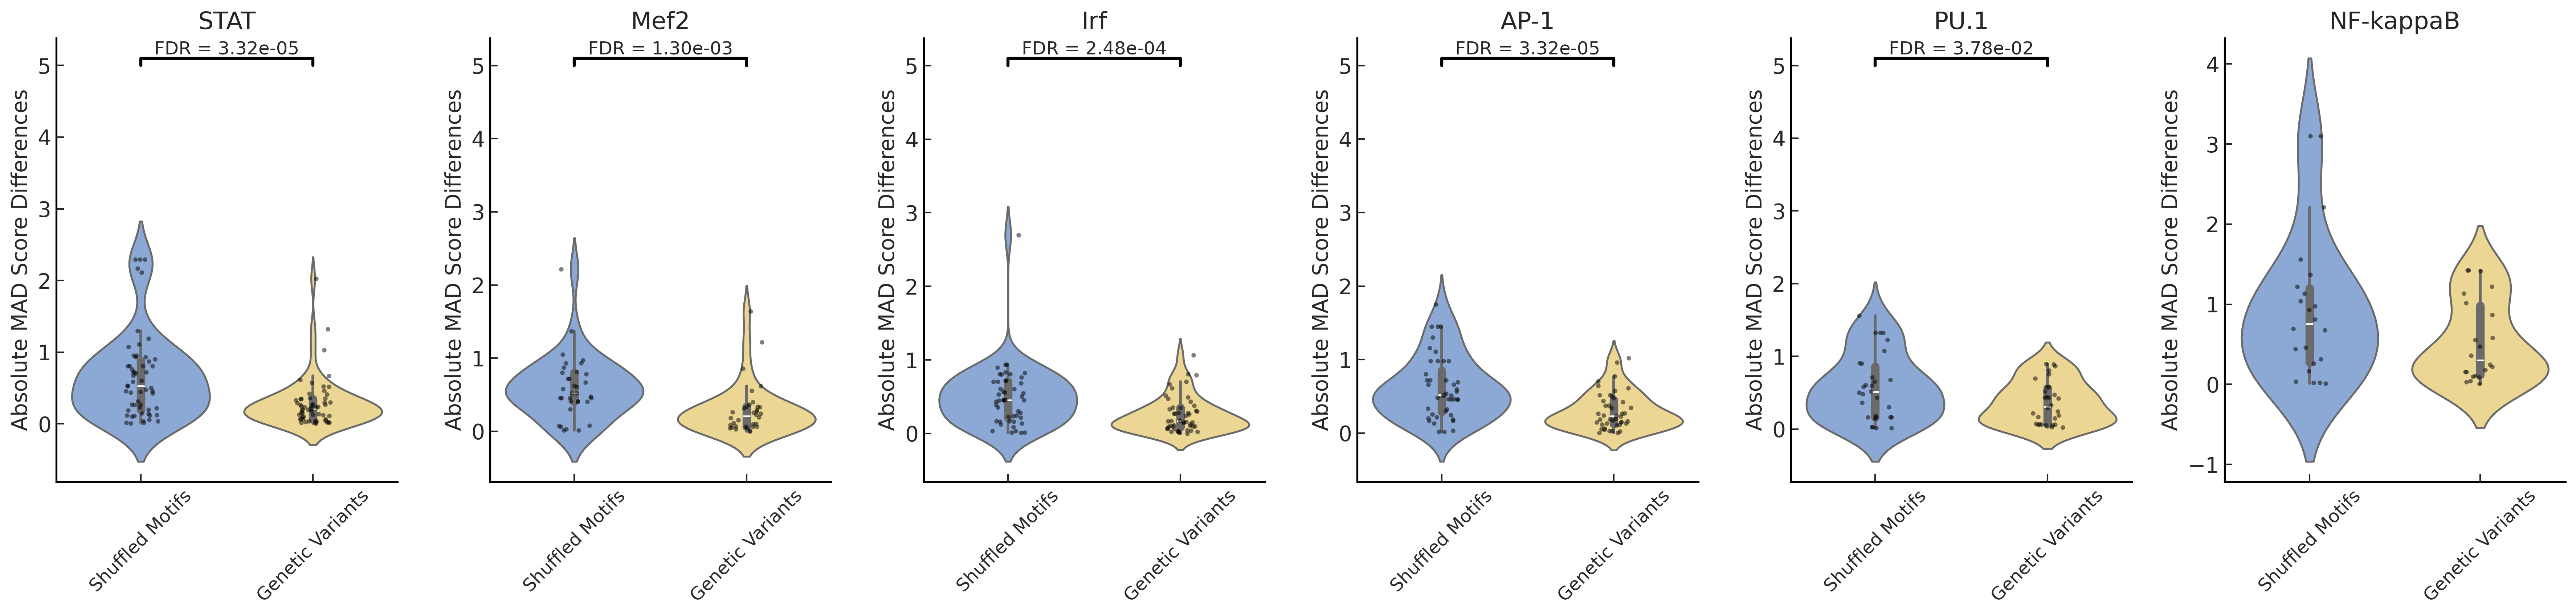

(array([3.31936882e-05, 1.30235801e-03, 2.47776030e-04, 3.31936882e-05,
        3.77955914e-02, 3.70531082e-01]),)

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings

# Suppress future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Update global Matplotlib font settings
plt.rcParams.update({
    'axes.titlesize': 21,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'font.size': 14
})

def process_data(index_file, ref_file, alt_file, filtered_df, motif, statistics):
    # Reading the data
    df_index2 = pd.read_csv(index_file, index_col=0)
    df_ref = pd.read_csv(ref_file, index_col=0)
    df_alt = pd.read_csv(alt_file, index_col=0)

    # Merging with index data
    df_ref = pd.merge(df_ref, df_index2, left_index=True, right_index=True, how='left')
    df_alt = pd.merge(df_alt, df_index2, left_index=True, right_index=True, how='left')

    # Filtering and processing data
    df_alt_index_motif = df_alt[df_alt[motif] == 1]
    df_alt_index_altonly = df_alt_index_motif[df_alt_index_motif.index.isin(filtered_df['alt'])]
    df_alt_final = pd.merge(filtered_df.set_index("alt"), df_alt_index_altonly, right_index=True, left_index=True)
    df_ref_final = df_ref.loc[df_alt_final.index]
    df_motif_final = df_alt.loc[df_alt_final["motif"]]
    df_alt_difference = df_alt_final[statistics] - df_ref_final[statistics]
    df_motif_difference = np.array(df_motif_final[statistics]) - np.array(df_ref_final[statistics])

    # Preparing final DataFrame
    combined_difference_abs = pd.DataFrame({
        'Shuffled Motifs': abs(df_motif_difference),
        'Genetic Variants': abs(np.array(df_alt_difference))
    }, index=df_alt_difference.index)
    combined_difference_reset = combined_difference_abs.reset_index()
    combined_long = combined_difference_reset.melt(id_vars=combined_difference_reset.columns[0],
                                                    value_vars=['Shuffled Motifs', 'Genetic Variants'])
    combined_long.columns = ['alt', 'Condition', 'MAD Score']

    return combined_long

def plot_violinplot(combined_data, subset1, title, subset2, p_values, offset=2, ax=None):
    # Increase Seaborn font scale
    sns.set(style="whitegrid", font_scale=1.5)
    plt.rcParams['figure.dpi'] = 300

    if ax is None:
        ax = plt.gca()  # Get the current active axes

    sns.violinplot(x='Condition', y='MAD Score', data=combined_data,
                   palette=["#80A6E2", "#FBDD85"], alpha=1, ax=ax)
    sns.stripplot(x='Condition', y='MAD Score', data=combined_data, jitter=True,
                  color='black', alpha=0.5, size=3, ax=ax)  # increased point size

    # Calculate the differences between subset1 and subset2
    differences = np.array(subset1) - np.array(subset2)

    # Perform Shapiro-Wilk test on the differences
    stat, p = stats.shapiro(differences)
    print(f'Differences - Statistics={stat}, p-value={p}')

    # Interpret the results
    alpha = 0.05  # significance level
    if p > alpha:
        print('Differences: Sample looks Gaussian (fail to reject H0)')
        t_statistic, p_value = stats.ttest_rel(subset1, subset2)
    else:
        print('Differences: Sample does not look Gaussian (reject H0)')
        statistic, p_value = stats.wilcoxon(subset1, subset2)

    # Append the p-value to the list for FDR correction
    p_values.append(p_value)

    # Refine grid and axis
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    # Rotate and set tick labels with larger font sizes
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=12)
    ax.tick_params(axis='x', direction='in', length=5, width=1)
    ax.tick_params(axis='y', direction='in', length=5, width=1)

    # Set axis labels and title with larger font sizes
    ax.set_ylabel('Absolute MAD Score Differences', fontsize=14)
    ax.set_xlabel('', fontsize=14)
    ax.set_title(title, fontsize=16)

def create_combined_plot_paired_t_test(ref, alt, save_file):
    # Transcription factors to plot
    tfs = ["STAT", "Mef2", "Irf", "AP-1", "PU.1", "NF-kappaB"]
    
    # Load filtered_df from a file or create it before calling the function
    filtered_df = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv")
    
    # Create a large figure to hold all subplots
    fig, axes = plt.subplots(1, len(tfs), figsize=(len(tfs) * 4, 6))  # Adjust the size as needed
    
    # List to store all p-values
    p_values = []
    
    for i, tf in enumerate(tfs):
        # Process data for each transcription factor
        combined_long = process_data('indexing/index_20240125_curated.csv',
                                     ref, alt,
                                     filtered_df, tf, 'mad.score')
        
        # Extract subsets for plotting
        subset1 = abs(combined_long[combined_long['Condition'] == 'Shuffled Motifs']['MAD Score'])
        subset2 = abs(combined_long[combined_long['Condition'] == 'Genetic Variants']['MAD Score'])
        
        # Plot the violin plot on the ith subplot and collect p-values
        plot_violinplot(combined_long, subset1, tf, subset2, p_values, offset=2, ax=axes[i])
    
    # Apply FDR correction after collecting all p-values
    rejected, corrected_p_values, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

    # Add corrected p-values to plots
    for i, ax in enumerate(axes):
        if corrected_p_values[i] <= 0.05:  # Significant after FDR correction
            y_coord = max(combined_long['MAD Score']) + 2  # Adjust offset as needed
            ax.plot([0, 0, 1, 1], [y_coord - 0.1, y_coord, y_coord, y_coord - 0.1], lw=2, c='black')
            ax.text(0.5, y_coord, f'FDR = {corrected_p_values[i]:.2e}', ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(save_file, format='pdf', dpi=300)
    plt.show()
    return corrected_p_values,
# Call the function to create the combined plot
create_combined_plot_paired_t_test(
    ref='enhancer_activities/THP1Macrophage_byAllele/20240912_MPRA3_MAD_mergedREF.csv',
    alt='enhancer_activities/THP1Macrophage_byAllele/20240912_MPRA3_MAD_mergedALT.csv',
    save_file="violinplot_motifdisrupt_madscore_tmp.pdf"
)


In [2]:
p_value

NameError: name 'p_value' is not defined

t-statistic: 1.673672806430091, p-value: 0.04961668072332554
t-statistic: -0.8200063803073055, p-value: 0.20751808668323385


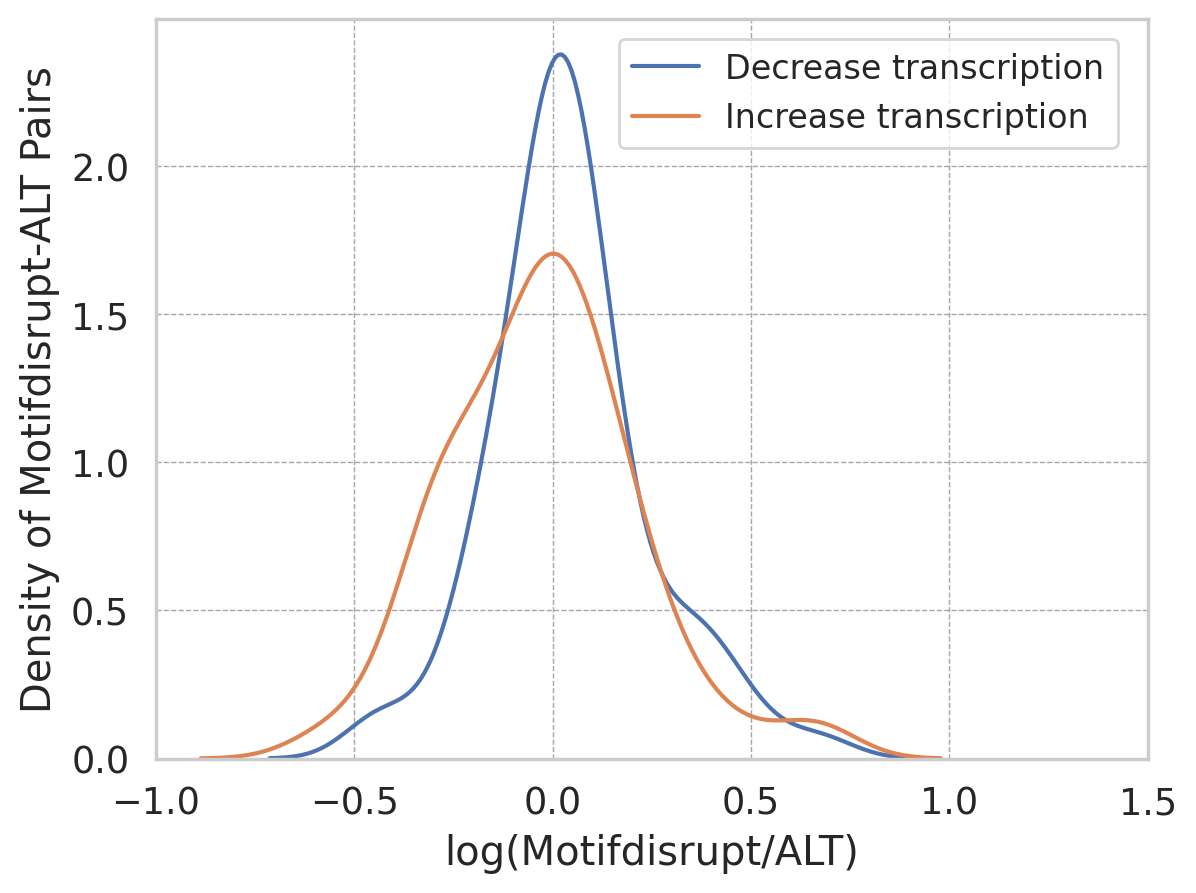

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import warnings

df_brain_allele=pd.read_csv("allele_differences_withoutcontrol/20240409_comparative_BrainR1R2merged20240404_allele.csv",index_col=0)
index = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv")

df= pd.DataFrame(df_brain_allele.loc[index["motif"]]['logFC'])
df.columns=["motif_logFC"] 
index = pd.merge(index,df,left_on="motif",right_index=True,how='left').drop_duplicates()

df= pd.DataFrame(df_brain_allele.loc[index["alt"]]['logFC'])
df.columns=["alt_logFC"] 
index = pd.merge(index,df,left_on="alt",right_index=True,how='left').drop_duplicates()

index_pos = index[(index['motif_logFC']>0) & (index['alt_logFC']>0)]

t_statistic, p_value = stats.ttest_rel(index_pos['motif_logFC'], index_pos['alt_logFC'],alternative='greater')

print(f"t-statistic: {t_statistic}, p-value: {p_value}")
import seaborn as sns

sns.kdeplot(index_pos['motif_logFC']-index_pos['alt_logFC'])


df_brain_allele=pd.read_csv("allele_differences_withoutcontrol/20240409_comparative_BrainR1R2merged20240404_allele.csv",index_col=0)
index = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv")

df= pd.DataFrame(df_brain_allele.loc[index["motif"]]['logFC'])
df.columns=["motif_logFC"] 
index = pd.merge(index,df,left_on="motif",right_index=True,how='left').drop_duplicates()

df= pd.DataFrame(df_brain_allele.loc[index["alt"]]['logFC'])
df.columns=["alt_logFC"] 
index = pd.merge(index,df,left_on="alt",right_index=True,how='left').drop_duplicates()

index_pos = index[(index['motif_logFC']<0) & (index['alt_logFC']<0)]

t_statistic, p_value = stats.ttest_rel(index_pos['motif_logFC'], index_pos['alt_logFC'],alternative='less')

print(f"t-statistic: {t_statistic}, p-value: {p_value}")
import seaborn as sns

sns.kdeplot(index_pos['motif_logFC']-index_pos['alt_logFC'])

plt.legend(["Decrease transcription","Increase transcription"],loc='center left', bbox_to_anchor=(0.45, 0.9),fontsize = 12)
plt.ylabel("Density of Motifdisrupt-ALT Pairs")
plt.xlabel("log(Motifdisrupt/ALT)")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.xlim(-1,1.5)
plt.show()

t-statistic: 3.6585072107657175, p-value: 0.00026834534748534477
t-statistic: -4.3143419000038135, p-value: 3.770381032779889e-05


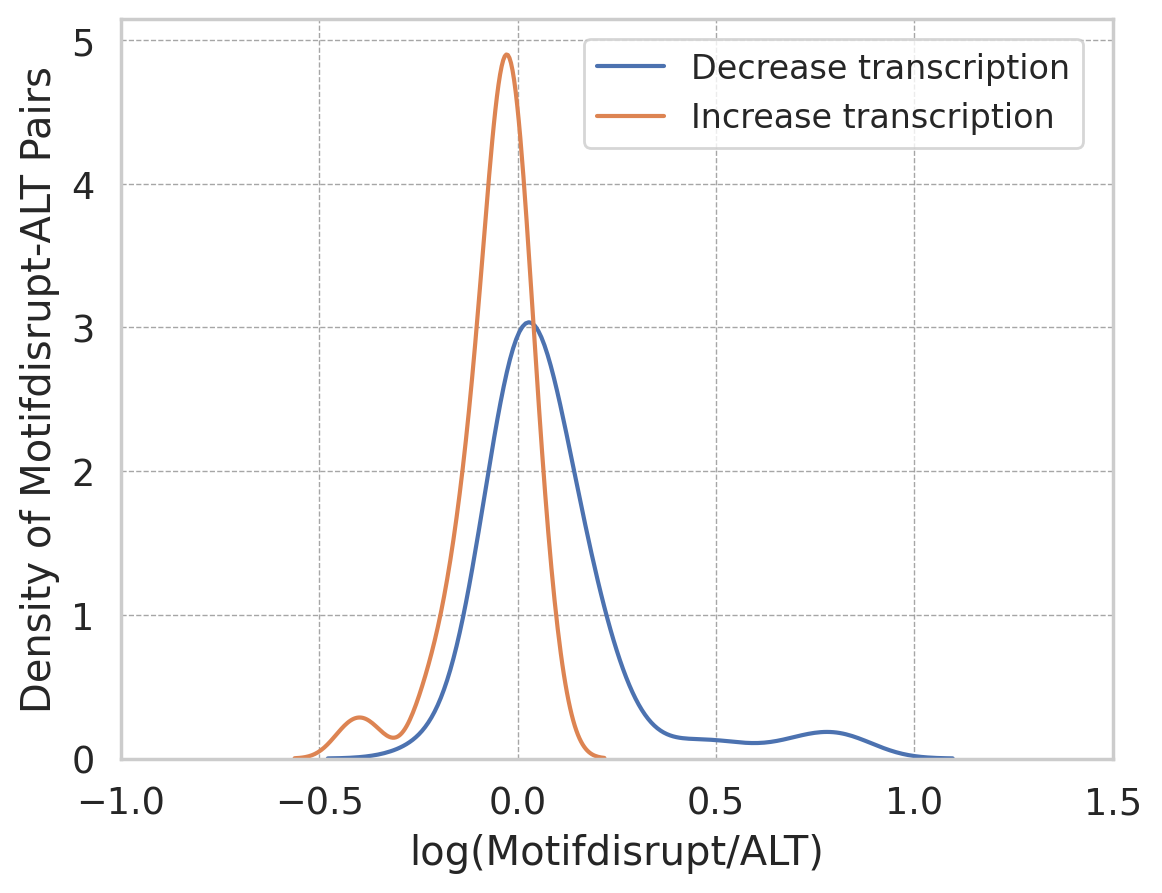

In [16]:
df_brain_allele=pd.read_csv("allele_differences_withoutcontrol/20240129_comparative_THP1Macrophage_allele.csv",index_col=0)
index = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv")

df= pd.DataFrame(df_brain_allele.loc[index["motif"]]['logFC'])
df.columns=["motif_logFC"] 
index = pd.merge(index,df,left_on="motif",right_index=True,how='left').drop_duplicates()

df= pd.DataFrame(df_brain_allele.loc[index["alt"]]['logFC'])
df.columns=["alt_logFC"] 
index = pd.merge(index,df,left_on="alt",right_index=True,how='left').drop_duplicates()

index_pos = index[(index['motif_logFC']>0) & (index['alt_logFC']>0)]

t_statistic, p_value = stats.ttest_rel(index_pos['motif_logFC'], index_pos['alt_logFC'],alternative='greater')

print(f"t-statistic: {t_statistic}, p-value: {p_value}")
import seaborn as sns

sns.kdeplot(index_pos['motif_logFC']-index_pos['alt_logFC'])


##################################################################################################################################
df_brain_allele=pd.read_csv("allele_differences_withoutcontrol/20240129_comparative_THP1Macrophage_allele.csv",index_col=0)
index = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv")

df= pd.DataFrame(df_brain_allele.loc[index["motif"]]['logFC'])
df.columns=["motif_logFC"] 
index = pd.merge(index,df,left_on="motif",right_index=True,how='left').drop_duplicates()

df= pd.DataFrame(df_brain_allele.loc[index["alt"]]['logFC'])
df.columns=["alt_logFC"] 
index = pd.merge(index,df,left_on="alt",right_index=True,how='left').drop_duplicates()

index_pos = index[(index['motif_logFC']<0) & (index['alt_logFC']<0)]

t_statistic, p_value = stats.ttest_rel(index_pos['motif_logFC'], index_pos['alt_logFC'],alternative='less')

print(f"t-statistic: {t_statistic}, p-value: {p_value}")
import seaborn as sns

sns.kdeplot(index_pos['motif_logFC']-index_pos['alt_logFC'])
plt.legend(["Decrease transcription","Increase transcription"],loc='center left', bbox_to_anchor=(0.45, 0.9),fontsize = 12)
plt.ylabel("Density of Motifdisrupt-ALT Pairs")
plt.xlabel("log(Motifdisrupt/ALT)")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.xlim(-1,1.5)
plt.show()

In [5]:
import os
import pandas as pd

# Directory containing the CSV files
directory_path = '/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_motif_only'

# Dictionary to store dataframes using file name as key
dataframes = {}

# Loop through each file in the directory
for filename in os.listdir(directory_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(directory_path, filename)
        # Read CSV file, use the first column as the index
        df = pd.read_csv(file_path, index_col=0)
        # Check if both 'logFC' and 'fdr' columns exist
        if 'logFC' in df.columns and 'fdr' in df.columns:
            # Set logFC to NaN if fdr is >= 0.05
            df.loc[df['fdr'] >= 0.05, 'logFC'] = float('nan')
            # Rename the logFC column to the file name (without extension)
            file_column_name = os.path.splitext(filename)[0]  # Remove .csv extension
            df = df[['logFC']].rename(columns={'logFC': file_column_name})
            dataframes[file_column_name] = df

# Combine all dataframes using an outer join to align indices
combined_df = pd.concat(dataframes.values(), axis=1, join='outer')  # Combine columns side-by-side

# List of specific columns to negate
columns_to_negate = [
    '20240922_comparative_THP1_IFNG_motif',
    '20240922_comparative_THP1_IFNB_motif',
    '20240922_comparative_THP1_LPSIFNG_motif',
    '20240922_comparative_THP1_Naive_motif'
]

# Check if the columns exist in the dataframe before negating
for col in columns_to_negate:
    if col in combined_df.columns:
        combined_df[col] = -combined_df[col]

In [6]:
combined_df

,20240719_comparative_THP1Monocyte_motif,20240812_comparative_HMC3_motif,20240922_comparative_THP1_IFNG_motif,20240611_comparative_THP1Macrophage_motif,20240616_comparative_BrainR1R2merged20240404_motif,20240922_comparative_THP1_IFNB_motif,20240719_comparative_HEK293T_motif,20240922_comparative_THP1_LPSIFNG_motif,20240922_comparative_THP1_Naive_motif
rs10130373:chr14:92466231:C:A:92465994:92466494:92466244_motifdisrupt,NaN,-0.155768,NaN,-0.171544,NaN,NaN,-0.148729,NaN,-0.056867
rs72838288:chr2:127135449:C:A:127135119:127135619:127135369_motifdisrupt,NaN,NaN,NaN,-0.040866,NaN,NaN,NaN,NaN,NaN
rs9304646:chr19:44947151:T:A:44946977:44947477:44947227_motifdisrupt,-0.361972,-0.604965,NaN,-0.502034,NaN,NaN,-0.404344,NaN,NaN
rs113046258:chr19:58183782:A:G:58182601:58184100:58183816_motifdisrupt,NaN,-0.136801,NaN,0.067527,NaN,NaN,-0.220483,NaN,NaN
rs113046258:chr19:58183782:A:G:58182737:58183975:58183741_motifdisrupt,0.357771,NaN,NaN,0.164776,0.209627,NaN,NaN,NaN,0.102938
...,...,...,...,...,...,...,...,...,...
rs9271068:chr6:32575674:C:G:32575391:32575891:32575641_motifdisrupt,NaN,0.150302,0.224604,0.100460,NaN,0.263034,0.202475,0.194907,0.233514
rs9271090:chr6:32576247:T:C:32576044:32576544:32576294_motifdisrupt,NaN,-0.129696,NaN,NaN,NaN,NaN,-0.214313,NaN,NaN
rs9271170:chr6:32577889:T:C:32577256:32578131:32577812_motifdisrupt,NaN,NaN,NaN,-0.101499,0.413414,NaN,-0.243702,NaN,NaN
rs9271174:chr6:32578040:C:G:32577256:32578131:32578057_motifdisrupt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
tissue_df = combined_df[[
       '20240812_comparative_HMC3_motif',
       '20240611_comparative_THP1Macrophage_motif',
       '20240616_comparative_BrainR1R2merged20240404_motif',
       '20240719_comparative_HEK293T_motif',]]

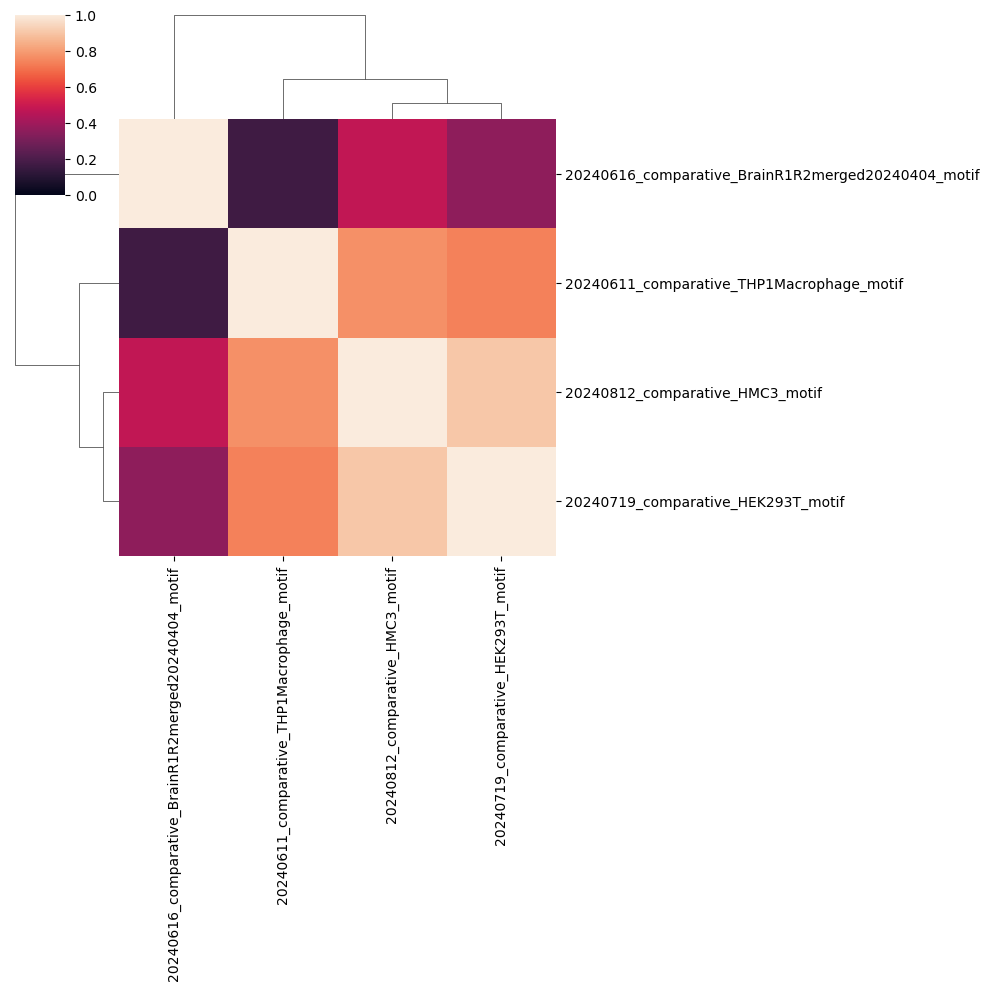

In [8]:
import seaborn as sns
sns.clustermap(tissue_df.corr('spearman'),vmin = 0)

In [9]:
df_index=pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_202401021.csv',index_col=0)
df_index = df_index[['Mef2',	'PU.1',	'Irf'	,'STAT',	'NF-kappaB',	'AP-1']]

In [10]:
df_alref=pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_motif_alt_ref_20240127.csv",index_col=0)

In [11]:
df_alref_sorted = df_alref.loc[tissue_df.index]


In [12]:
df_alref_sorted_motif = pd.merge(df_alref_sorted,df_index.loc[df_alref.loc[tissue_df.index]['alt']],left_on="alt",right_index=True)

In [13]:
df_final = pd.merge(tissue_df,df_alref_sorted_motif,left_index=True,right_index=True).reset_index().drop_duplicates(subset="index").set_index('index')
df_final

,20240812_comparative_HMC3_motif,20240611_comparative_THP1Macrophage_motif,20240616_comparative_BrainR1R2merged20240404_motif,20240719_comparative_HEK293T_motif,ref,alt,Mef2,PU.1,Irf,STAT,NF-kappaB,AP-1
index,,,,,,,,,,,,
rs10130373:chr14:92466231:C:A:92465994:92466494:92466244_motifdisrupt,-0.155768,-0.171544,NaN,-0.148729,ref:rs4904922:PEAKCENTER:chr14:92466135:G:C:92...,alt:rs10130373:PEAKCENTER:chr14:92466231:C:A:9...,0,1,0,0,0,0
rs72838288:chr2:127135449:C:A:127135119:127135619:127135369_motifdisrupt,NaN,-0.040866,NaN,NaN,ref:rs72838287:PEAKCENTER:chr2:127135380:C:G:1...,alt:rs72838288:PEAKCENTER:chr2:127135449:C:A:1...,0,0,0,0,0,1
rs9304646:chr19:44947151:T:A:44946977:44947477:44947227_motifdisrupt,-0.604965,-0.502034,NaN,-0.404344,ref:rs9304646:PEAKCENTER:chr19:44947151:T:A:44...,alt:rs9304646:PEAKCENTER:chr19:44947151:T:A:44...,0,0,0,1,0,0
rs113046258:chr19:58183782:A:G:58182601:58184100:58183816_motifdisrupt,-0.136801,0.067527,NaN,-0.220483,ref:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,alt:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,1,0,1,1,0,1
rs113046258:chr19:58183782:A:G:58182737:58183975:58183741_motifdisrupt,NaN,0.164776,0.209627,NaN,ref:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,alt:rs113046258:PEAKCENTER:chr19:58183782:A:G:...,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
rs9271068:chr6:32575674:C:G:32575391:32575891:32575641_motifdisrupt,0.150302,0.100460,NaN,0.202475,ref:rs9271063:PEAKCENTER:chr6:32575584:A:G:325...,alt:rs9271068:PEAKCENTER:chr6:32575674:C:G:325...,0,0,0,0,1,0
rs9271090:chr6:32576247:T:C:32576044:32576544:32576294_motifdisrupt,-0.129696,NaN,NaN,-0.214313,ref:rs9271090:PEAKCENTER:chr6:32576247:T:C:325...,alt:rs9271090:PEAKCENTER:chr6:32576247:T:C:325...,0,0,0,0,1,0
rs9271170:chr6:32577889:T:C:32577256:32578131:32577812_motifdisrupt,NaN,-0.101499,0.413414,-0.243702,ref:rs9271163:PEAKCENTER:chr6:32577733:C:T:325...,alt:rs9271170:PEAKCENTER:chr6:32577889:T:C:325...,0,0,0,1,0,0


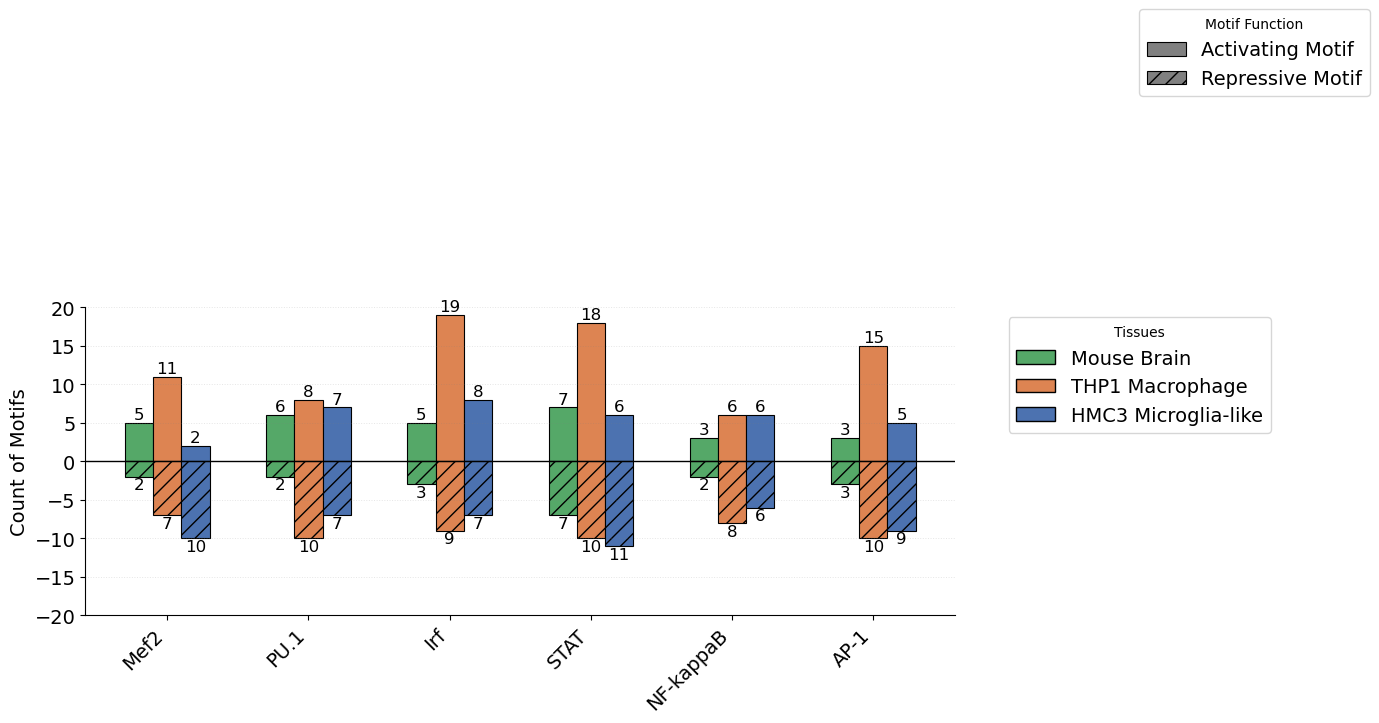

In [18]:
import matplotlib.pyplot as plt

# Reordered tissues: Brain, THP1, HMC3
tissues = [
    '20240616_comparative_BrainR1R2merged20240404_motif',    # Will be "Mouse Brain"
    '20240611_comparative_THP1Macrophage_motif',             # Will be "THP1 Macrophage"
    '20240812_comparative_HMC3_motif'                        # Will be "HMC3 Microglia-like"
]

tfs = ['Mef2', 'PU.1', 'Irf', 'STAT', 'NF-kappaB', 'AP-1']

# Nature-compatible color palette
tissue_colors = {
    '20240616_comparative_BrainR1R2merged20240404_motif': '#55A868',  # Green (Brain)
    '20240611_comparative_THP1Macrophage_motif': '#DD8452',           # Orange (THP1)
    '20240812_comparative_HMC3_motif': '#4C72B0'                      # Blue (HMC3)
}

# Updated legend labels
legend_labels = {
    '20240616_comparative_BrainR1R2merged20240404_motif': 'Mouse Brain',
    '20240611_comparative_THP1Macrophage_motif': 'THP1 Macrophage',
    '20240812_comparative_HMC3_motif': 'HMC3 Microglia-like'
}

results = {tf: {'>0': [], '<0': [], 'total': []} for tf in tfs}

for tf in tfs:
    filtered_df = df_final[df_final[tf] == 1]
    for tissue in tissues:
        tissue_values = filtered_df[tissue].dropna()
        positive_count = (tissue_values > 0).sum()
        negative_count = (tissue_values < 0).sum()
        total_count = positive_count + negative_count if (positive_count + negative_count) > 0 else 1
        results[tf]['>0'].append(positive_count)
        results[tf]['<0'].append(negative_count)
        results[tf]['total'].append(total_count)

fig, ax = plt.subplots(figsize=(12, 4))

bar_width = 0.2
x = range(len(tfs))

# Draw a baseline at y=0
ax.axhline(0, color='black', linewidth=1)

# Add light, dotted, transparent gridlines
ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='gray', alpha=0.2)

# Offsets for the labels so they don't overlap with the bar edges
pos_label_offset = 0.1
neg_label_offset = -0.1

for i, tf in enumerate(tfs):
    for j, tissue in enumerate(tissues):
        positive_count = results[tf]['>0'][j]
        negative_count = results[tf]['<0'][j]
        x_position = i + j * bar_width
        
        # Positive bars above zero
        if positive_count > 0:
            ax.bar(
                x_position, 
                positive_count, 
                width=bar_width,
                color=tissue_colors[tissue],
                edgecolor='black',
                linewidth=0.8
            )
            # Add label at the top of the positive bar
            ax.text(
                x_position,
                positive_count + pos_label_offset,
                str(positive_count),
                ha='center',
                va='bottom',
                fontsize=12
            )
        
        # Negative bars below zero
        if negative_count > 0:
            ax.bar(
                x_position,
                -negative_count, 
                width=bar_width,
                color=tissue_colors[tissue],
                edgecolor='black',
                linewidth=0.8,
                hatch='//'
            )
            # Add label at the bottom of the negative bar
            ax.text(
                x_position,
                -(negative_count) + neg_label_offset,
                str(negative_count),
                ha='center',
                va='top',
                fontsize=12
            )

# Customize plot
ax.set_ylabel('Count of Motifs', fontsize=14)
ax.set_xticks([pos + (bar_width * (len(tissues)-1) / 2) for pos in x])
ax.set_xticklabels(tfs, rotation=45, ha='right', fontsize=14)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend for tissues
tissue_patches = [plt.Rectangle((0,0),1,1, facecolor=tissue_colors[t], edgecolor='black') for t in tissues]
tissue_legend_labels = [legend_labels[t] for t in tissues]
leg_tissues = ax.legend(tissue_patches, tissue_legend_labels, title='Tissues', loc='upper left', bbox_to_anchor=(1.05, 1.0),fontsize=14)

# Legend for sign (>0 or <0)
pos_patch = plt.Rectangle((0,0),1,1, facecolor='gray', edgecolor='black', linewidth=0.8)
neg_patch = plt.Rectangle((0,0),1,1, facecolor='gray', edgecolor='black', linewidth=0.8, hatch='//')
leg_sign = ax.legend([pos_patch, neg_patch], ['Activating Motif', 'Repressive Motif'], title='Motif Function', 
                     loc='upper left', bbox_to_anchor=(1.2, 2),fontsize=14)

# Add the tissue legend and sign legend
ax.add_artist(leg_tissues)
plt.ylim(-20,20)
plt.yticks(fontsize=14)
# Adjust layout to leave space on the right for legends
fig.subplots_adjust(right=0.85)  # Leave space on the right for the legends

# Save the figure as a high-resolution PDF
plt.savefig('stacked_barplot_motifdisrupt.pdf', dpi=300, bbox_inches='tight')
plt.show()
